# Detection, segementation, and scoring of a project

In [3]:
import os
import pandas as pd
from tqdm import tqdm
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


In [4]:
os.chdir(os.getcwd())

Import the the base ShapeScore functions. Directory must be set to main ShapeScore directory.

In [5]:
from shapescore import detection,maskgen,predict_survival,metrics

Select the project directory. Project directories for worm survival prediction contain three main elements: 1) the input_raw folder, which contains .jpg images of each well, 2) the plate_layouts folder which contains a .csv file for the layout of each well plate represented in the titles of the images in the input_raw folder, and 3) fields.csv, which describes the order of identifiers contained in the input_raw images separated by underscores. For this particular project, the naming convention for images is timepoint_plate_well_opticalconfig.jpg.

In [ ]:
project='example_detection'
proj_dir=project+'/example_detection'

Detect worms, save bounding boxes to bounding_boxes.csv

In [8]:
detection.predict_bb(proj_dir)

Detecting objects...


100%|██████████| 28/28 [00:04<00:00,  5.82it/s]


Use bounding_boxes.csv to predict worm masks with SAM 2, and then save .jpgs to project/example_detection/processed_mask. Segmentaiton will pick up where it left off if function is interrupted. Use force=True to force restart of segmentation regardless of previous runs.

In [9]:
maskgen.predict_segmentation(proj_dir)

Generating masks...


1it [00:01,  1.31s/it]


Predict probability of survival on each mask output and save to maskpreds.csv.

In [10]:
predict_survival.predict_survival(proj_dir)

Predicting survival...


100%|██████████| 744/744 [00:10<00:00, 72.37it/s] 


Calculate other metrics on each mask and combine with maskpreds.csv, save to res.csv.

In [13]:
metrics.metrics(proj_dir, project=project)

Calculating metrics...


100%|██████████| 744/744 [00:00<00:00, 1718.24it/s]


Compare individual worm mask probabilites of wild-type (N2) worms veruss age-1 mutants (TJ1052) after 11 hour heat shock.

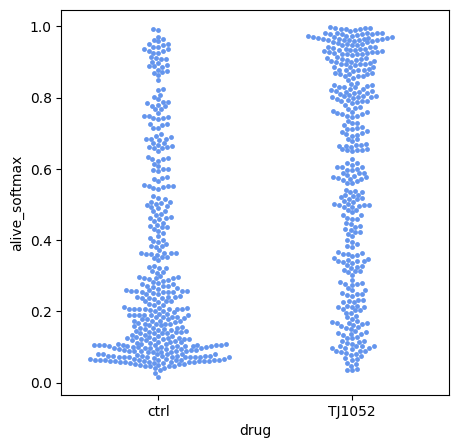

In [16]:
from shapescore.utils import make_layout_df
import seaborn as sns
res=pd.read_csv('project/'+project+'/res/res.csv',index_col=['well','plate'])
layout=make_layout_df('project/'+project)
res['drug']=layout.loc[res.index]['drug']

plt.figure(figsize=(5, 5))
sns.swarmplot(data=res,x='drug',y='alive_softmax', 
              color='cornflowerblue', size=3.5, order=['ctrl','TJ1052'])
plt.show()


Compare well average scores of wild-type (N2) worms veruss age-1 mutants (TJ1052) after 11 hour heat shock

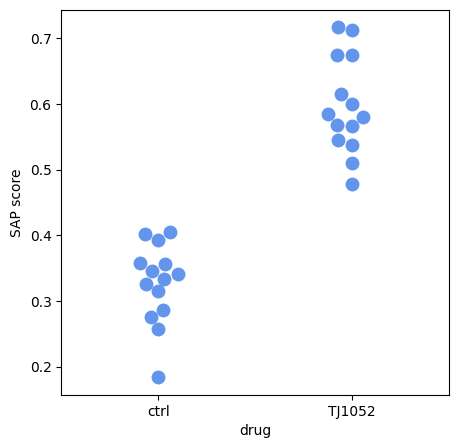

In [17]:
res_well=res.reset_index()[['alive_softmax','drug', 'well']].groupby(['drug','well']).mean().reset_index()

plt.figure(figsize=(5, 5))
sns.swarmplot(data=res_well,x='drug',y='alive_softmax', 
              color='cornflowerblue', size=10, order=['ctrl','TJ1052'])
plt.ylabel('SAP score')
plt.show()